<a href="https://colab.research.google.com/github/sanikatakarkhede/ML_models-TAE-1/blob/main/ML_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TOPIC :- Email Spam Detection

ML TAE 1

Group No.3: Riya Nitnaware_CS23015 , Sanika Takarkhede_CS23016

In [ ]:

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [22]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [4]:
# STEP 2: Load Dataset
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive/ML_dataset/spam.csv"
df = pd.read_csv(path, encoding='latin-1')

In [6]:
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [7]:
print(df.shape)

(5572, 5)


In [8]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [9]:
df = df.iloc[:, :2]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [10]:
print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [11]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
None


In [18]:
# STEP 3: Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label']


In [23]:
# STEP 4: Confusion Matrix Function
def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='yellow')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [24]:
# 80:20 SPLIT
print("\n========= 80:20 SPLIT =========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results_80 = {}


========= 80:20 SPLIT =========



--- Logistic Regression ---
Accuracy: 0.9632286995515695
Confusion Matrix:
 [[965   0]
 [ 41 109]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



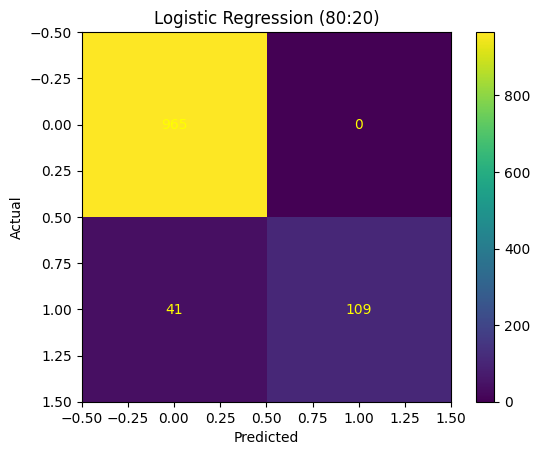

In [25]:
# 1. Logistic Regression
print("\n--- Logistic Regression ---")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

cm_lr = confusion_matrix(y_test, pred_lr)
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Confusion Matrix:\n", cm_lr)
print(classification_report(y_test, pred_lr))
plot_confusion_matrix(cm_lr, "Logistic Regression (80:20)")

results_80["Logistic Regression"] = accuracy_score(y_test, pred_lr)



--- Decision Tree ---
Accuracy: 0.9668161434977578
Confusion Matrix:
 [[948  17]
 [ 20 130]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       965
           1       0.88      0.87      0.88       150

    accuracy                           0.97      1115
   macro avg       0.93      0.92      0.93      1115
weighted avg       0.97      0.97      0.97      1115



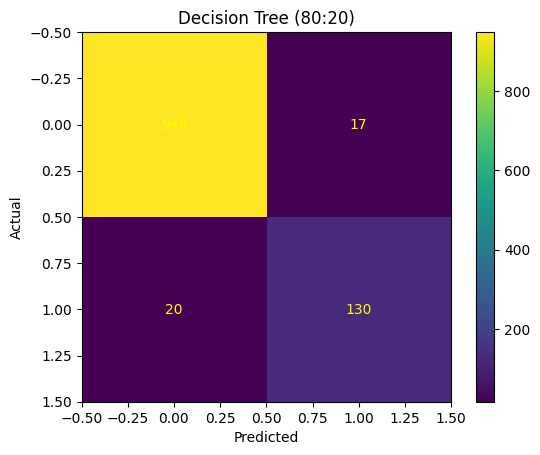

In [26]:
# 2. Decision Tree
print("\n--- Decision Tree ---")
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

cm_dt = confusion_matrix(y_test, pred_dt)
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Confusion Matrix:\n", cm_dt)
print(classification_report(y_test, pred_dt))
plot_confusion_matrix(cm_dt, "Decision Tree (80:20)")

results_80["Decision Tree"] = accuracy_score(y_test, pred_dt)


--- Naive Bayes ---
Accuracy: 0.9623318385650225
Confusion Matrix:
 [[965   0]
 [ 42 108]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



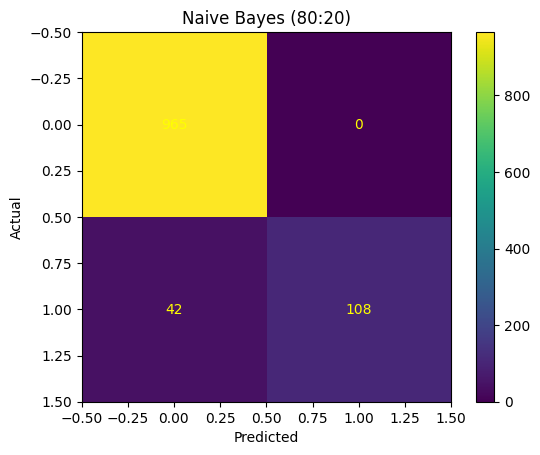

In [27]:
# 3. Naive Bayes
print("\n--- Naive Bayes ---")
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

cm_nb = confusion_matrix(y_test, pred_nb)
print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Confusion Matrix:\n", cm_nb)
print(classification_report(y_test, pred_nb))
plot_confusion_matrix(cm_nb, "Naive Bayes (80:20)")

results_80["Naive Bayes"] = accuracy_score(y_test, pred_nb)


--- SVM ---
Accuracy: 0.9766816143497757
Confusion Matrix:
 [[965   0]
 [ 26 124]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



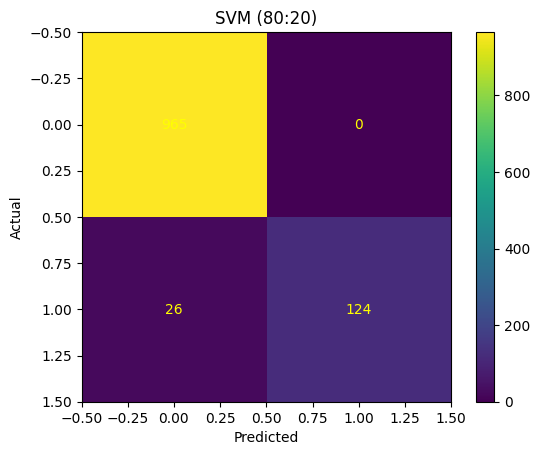

In [28]:
# 4. SVM
print("\n--- SVM ---")
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

cm_svm = confusion_matrix(y_test, pred_svm)
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Confusion Matrix:\n", cm_svm)
print(classification_report(y_test, pred_svm))
plot_confusion_matrix(cm_svm, "SVM (80:20)")

results_80["SVM"] = accuracy_score(y_test, pred_svm)


--- Random Forest ---
Accuracy: 0.9757847533632287
Confusion Matrix:
 [[965   0]
 [ 27 123]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



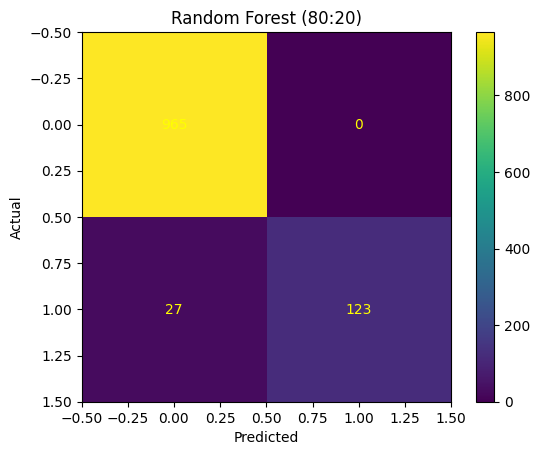

In [29]:
# 5. Random Forest
print("\n--- Random Forest ---")
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, pred_rf)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Confusion Matrix:\n", cm_rf)
print(classification_report(y_test, pred_rf))
plot_confusion_matrix(cm_rf, "Random Forest (80:20)")

results_80["Random Forest"] = accuracy_score(y_test, pred_rf)


--- KNN ---
Accuracy: 0.9130044843049328
Confusion Matrix:
 [[965   0]
 [ 97  53]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       965
           1       1.00      0.35      0.52       150

    accuracy                           0.91      1115
   macro avg       0.95      0.68      0.74      1115
weighted avg       0.92      0.91      0.89      1115



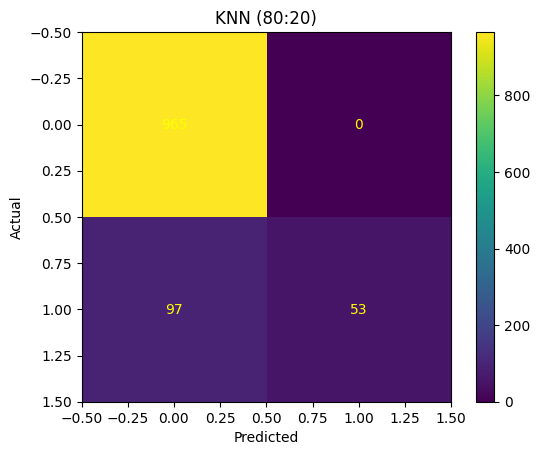

In [30]:
# 6. KNN
print("\n--- KNN ---")
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, pred_knn)
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Confusion Matrix:\n", cm_knn)
print(classification_report(y_test, pred_knn))
plot_confusion_matrix(cm_knn, "KNN (80:20)")

results_80["KNN"] = accuracy_score(y_test, pred_knn)

In [32]:
# ===== 80:20 COMPARISON =====
print("\n===== 80:20 FINAL COMPARISON =====")
for model, acc in results_80.items():
    print(f"{model}: {acc:.4f}")

best_80 = max(results_80, key=results_80.get)
print("\n Best Model (80:20):", best_80)


===== 80:20 FINAL COMPARISON =====
Logistic Regression: 0.9632
Decision Tree: 0.9668
Naive Bayes: 0.9623
SVM: 0.9767
Random Forest: 0.9758
KNN: 0.9130

 Best Model (80:20): SVM


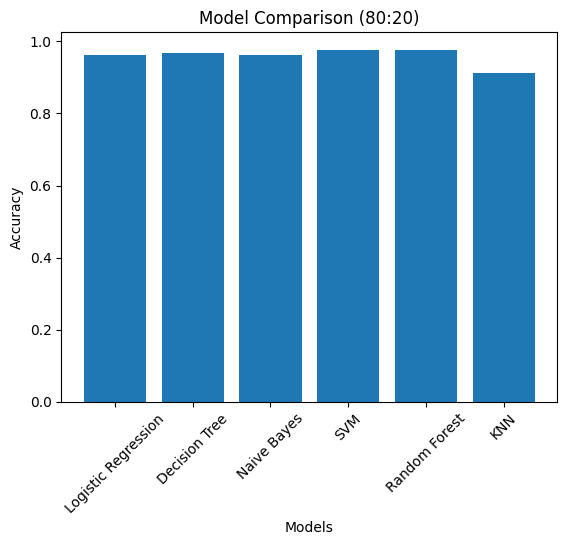

In [35]:
plt.figure()

models = list(results_80.keys())
accuracy = list(results_80.values())

plt.bar(models, accuracy)

plt.xticks(rotation=45)
plt.title("Model Comparison (80:20)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [33]:
#  70:30 SPLIT
print("\n========= 70:30 SPLIT =========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

results_70 = {}



========= 70:30 SPLIT =========



--- Logistic Regression ---
Accuracy: 0.9575358851674641
Confusion Matrix:
 [[1453    0]
 [  71  148]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1453
           1       1.00      0.68      0.81       219

    accuracy                           0.96      1672
   macro avg       0.98      0.84      0.89      1672
weighted avg       0.96      0.96      0.95      1672



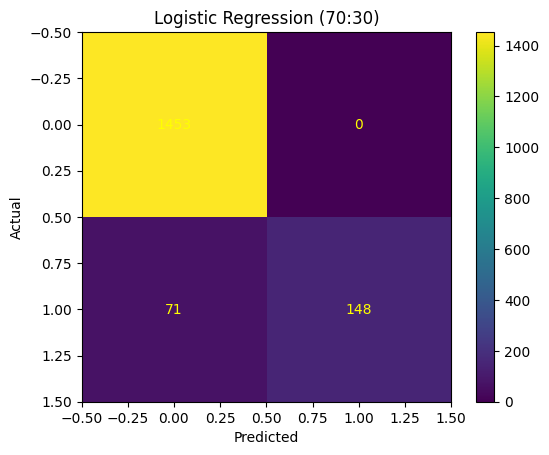


--- Decision Tree ---
Accuracy: 0.9659090909090909
Confusion Matrix:
 [[1429   24]
 [  33  186]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1453
           1       0.89      0.85      0.87       219

    accuracy                           0.97      1672
   macro avg       0.93      0.92      0.92      1672
weighted avg       0.97      0.97      0.97      1672



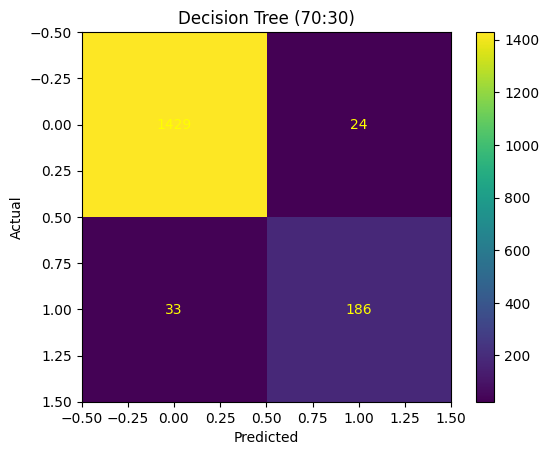


--- Naive Bayes ---
Accuracy: 0.9569377990430622
Confusion Matrix:
 [[1453    0]
 [  72  147]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1453
           1       1.00      0.67      0.80       219

    accuracy                           0.96      1672
   macro avg       0.98      0.84      0.89      1672
weighted avg       0.96      0.96      0.95      1672



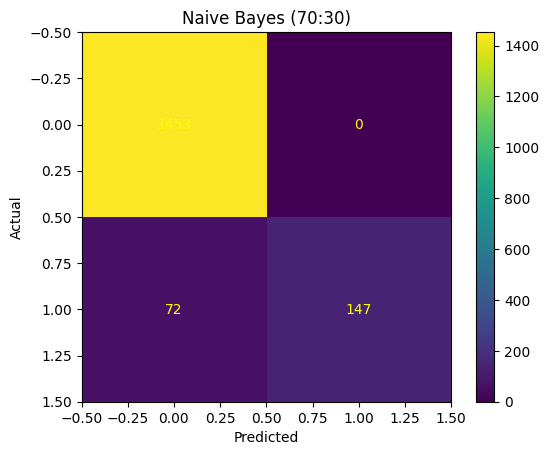


--- SVM ---
Accuracy: 0.9754784688995215
Confusion Matrix:
 [[1453    0]
 [  41  178]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1453
           1       1.00      0.81      0.90       219

    accuracy                           0.98      1672
   macro avg       0.99      0.91      0.94      1672
weighted avg       0.98      0.98      0.97      1672



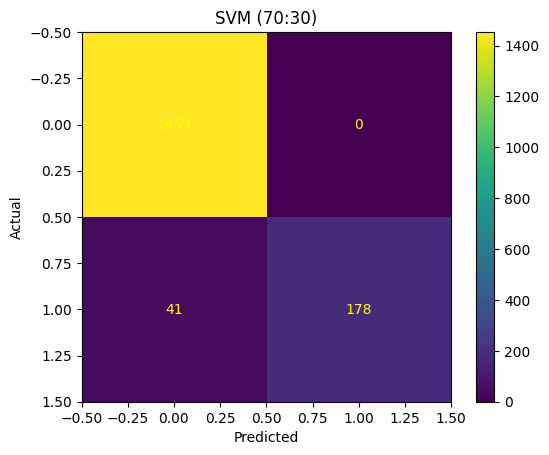


--- Random Forest ---
Accuracy: 0.9760765550239234
Confusion Matrix:
 [[1453    0]
 [  40  179]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1453
           1       1.00      0.82      0.90       219

    accuracy                           0.98      1672
   macro avg       0.99      0.91      0.94      1672
weighted avg       0.98      0.98      0.98      1672



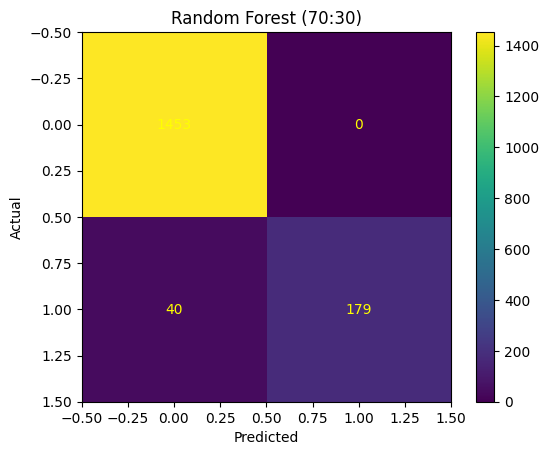


--- KNN ---
Accuracy: 0.9102870813397129
Confusion Matrix:
 [[1453    0]
 [ 150   69]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1453
           1       1.00      0.32      0.48       219

    accuracy                           0.91      1672
   macro avg       0.95      0.66      0.72      1672
weighted avg       0.92      0.91      0.89      1672



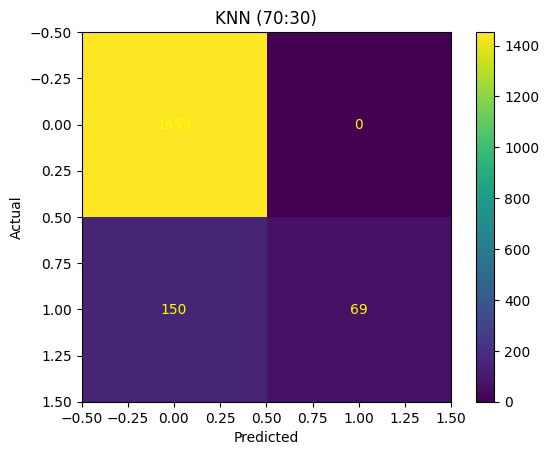

In [34]:
for name, model in {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_test, pred))
    plot_confusion_matrix(cm, f"{name} (70:30)")

    results_70[name] = accuracy_score(y_test, pred)


In [37]:
# ===== 70:30 COMPARISON =====
print("\n===== 70:30 FINAL COMPARISON =====")
for model, acc in results_70.items():
    print(f"{model}: {acc:.4f}")

best_70 = max(results_70, key=results_70.get)
print("\n Best Model (70:30):", best_70)



===== 70:30 FINAL COMPARISON =====
Logistic Regression: 0.9575
Decision Tree: 0.9659
Naive Bayes: 0.9569
SVM: 0.9755
Random Forest: 0.9761
KNN: 0.9103

 Best Model (70:30): Random Forest


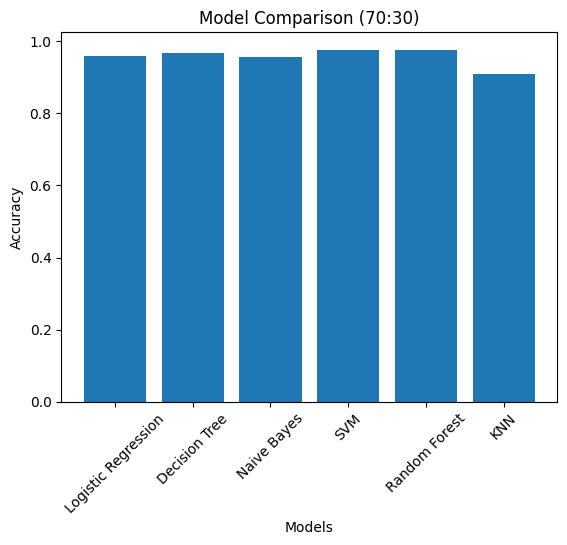

In [38]:
plt.figure()
models = list(results_70.keys())
accuracy = list(results_70.values())
plt.bar(models, accuracy)
plt.xticks(rotation=45)
plt.title("Model Comparison (70:30)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [39]:
#  FINAL COMPARISON
print("\n===== FINAL SPLIT COMPARISON =====")

for model in results_80:
    print(f"{model} -> 80:20: {results_80[model]:.4f} | 70:30: {results_70[model]:.4f}")


===== FINAL SPLIT COMPARISON =====
Logistic Regression -> 80:20: 0.9632 | 70:30: 0.9575
Decision Tree -> 80:20: 0.9668 | 70:30: 0.9659
Naive Bayes -> 80:20: 0.9623 | 70:30: 0.9569
SVM -> 80:20: 0.9767 | 70:30: 0.9755
Random Forest -> 80:20: 0.9758 | 70:30: 0.9761
KNN -> 80:20: 0.9130 | 70:30: 0.9103


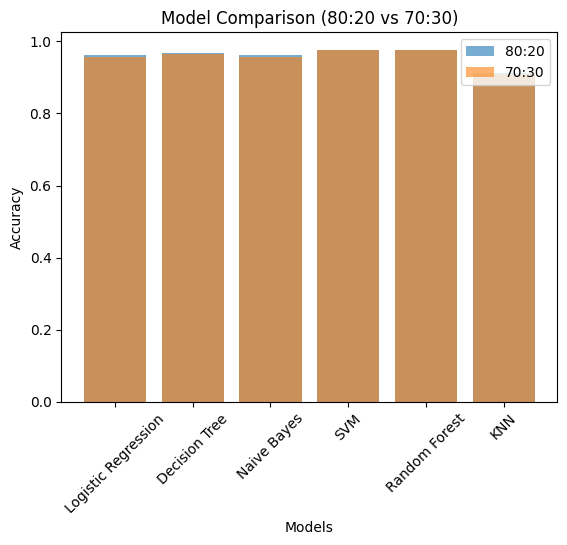

In [40]:
#  GRAPH
# ================================
plt.figure()

models = list(results_80.keys())

plt.bar(models, results_80.values(), alpha=0.6, label='80:20')
plt.bar(models, results_70.values(), alpha=0.6, label='70:30')

plt.xticks(rotation=45)
plt.title("Model Comparison (80:20 vs 70:30)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [42]:

#  OVERALL SPLIT COMPARISON
avg_80 = sum(results_80.values()) / len(results_80)
avg_70 = sum(results_70.values()) / len(results_70)
print("\n===== OVERALL SPLIT COMPARISON =====")
print(f"Average Accuracy (80:20): {avg_80:.4f}")
print(f"Average Accuracy (70:30): {avg_70:.4f}")
if avg_80 > avg_70:
    print("\n 80:20 split is better for this dataset")
else:
    print("\n 70:30 split is better for this dataset")


===== OVERALL SPLIT COMPARISON =====
Average Accuracy (80:20): 0.9596
Average Accuracy (70:30): 0.9570

 80:20 split is better for this dataset


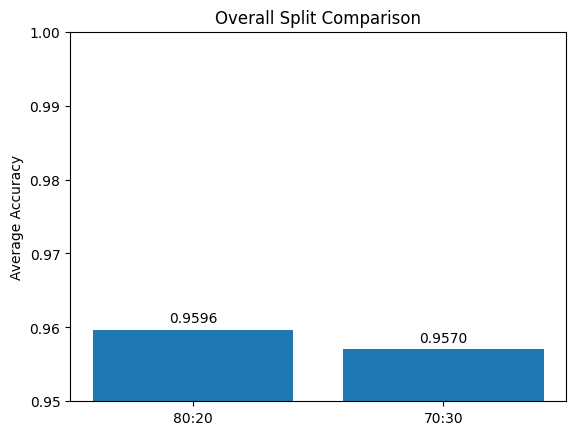

In [44]:
plt.figure()
splits = ['80:20', '70:30']
accuracy = [avg_80, avg_70]
plt.bar(splits, accuracy)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.ylim(0.95, 1.0)
plt.title("Overall Split Comparison")
plt.ylabel("Average Accuracy")
plt.show()